In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
from optuna.visualization import plot_parallel_coordinate
from optuna.visualization import plot_pareto_front
from optuna.importance import get_param_importances
from optuna.samplers import RandomSampler
from Testing.RTLO import *
from Testing.Cloud import *
from Testing.AutoCloud import *
from Functions.RLS import *
from Functions.Utils import *
from Functions.TedaGraphs import *

dir_hi = r"C:\Artigo_J3C_V2\VMD10\HI"
dir_rs = r"C:\Artigo_J3C_V2\VMD10\RS6_def\S2_A1_Q10_W10_RS_raw\RS1"
brng = 'Bearing1_1.csv'
brngs1 = ['Bearing1_1.csv','Bearing2_2.csv','Bearing1_2.csv','Bearing1_3.csv','Bearing2_5.csv']
Mp=[1.9249999999999998, 10, 8, True]
Mp2 = [1e-7,	0.1,	0.01,	1e-7,	18,	3,	24]
m, nRS, st, drop = Mp
D,N1, N2, N3,nHI, nR,tau = Mp2

In [11]:
def objective(trial):
    m = trial.suggest_float('m', 1.4, 2.0,step=0.005)
    nRS = trial.suggest_int('nRS', 2, 15) 
    st = trial.suggest_int('st', 0, 10) 
    drop = trial.suggest_categorical('drop', [False, False]) 
    brngs = brngs1[:3]
    vgrnls,ngrnls = np.array([]),np.array([])
    init = (st+nRS)
    Grncreated = None
    lenRun=0

    for i,brng in enumerate(brngs):
        df_RS = (pd.read_csv(os.path.join(dir_rs,brng)).abs()).iloc[:,:-1]
        df_HI = (pd.read_csv(os.path.join(dir_hi,brng)).abs()).iloc[:,:-1]
        if drop: df_RS = df_RS.drop(columns='Y')
        RS = process_RS(df_RS,nRS)
        HI = process_HI(df_HI,nHI=nHI,init=init)
        xS,yS,zS = RS[st:-2], HI[:-1], HI[1:]

        if i==0: teda=AutoCloud(m=m, nS=len(xS[0]), nI=len(yS[0]), nR=nR, nO=len(yS[0]), 
                            ηS= [N1, N2, N3], tau=tau, decay=D,eol=0.2,fator=1,
                            st=init,end=len(df_RS)-init,wta=True,ep=0.1) 
        
        elif i>0: teda.reset_rul()

        for j,_ in enumerate(xS):
            x= xS[j]
            teda.run(X=x)
                
        #if i == 0: 
        #Grncreated = len(teda.c)
        #trial.report(Grncreated, step=j + lenRun)
        #if trial.should_prune(): raise optuna.TrialPruned()

    for cloud in teda.c[:]:
        cloud.calc_Dmax(teda.xI,teda.xF)
        cloud.calc_v(k=teda.k)
        vgrnls = np.append(vgrnls,cloud.v*cloud.n)
        ngrnls = np.append(ngrnls,cloud.n)
    return np.sum(vgrnls)/np.sum(ngrnls)
pruner=optuna.pruners.ThresholdPruner(upper=6, lower=2)
study = optuna.create_study(
    direction="maximize",
    #storage="sqlite:///" + f'98_Optuna/{FileName}_Grnls.db',
    #study_name=f'P{7}',
    #sampler=RandomSampler(),
    pruner=pruner,
    load_if_exists=True)
study.optimize(objective, n_trials=100)
best_params = study.best_params
Mp = list(best_params.values())
print('Erro:', study.best_value, 'parameters: ', Mp)

[I 2026-03-12 15:34:26,077] A new study created in memory with name: no-name-76eab866-e398-4dd5-a920-cfa168108b6b
[I 2026-03-12 15:34:26,179] Trial 0 finished with value: 0.03785633267849192 and parameters: {'m': 1.6749999999999998, 'nRS': 7, 'st': 10, 'drop': False}. Best is trial 0 with value: 0.03785633267849192.
[I 2026-03-12 15:34:26,308] Trial 1 finished with value: 0.03502635141536817 and parameters: {'m': 1.47, 'nRS': 6, 'st': 0, 'drop': False}. Best is trial 0 with value: 0.03785633267849192.
[I 2026-03-12 15:34:26,420] Trial 2 finished with value: 0.0328462730641202 and parameters: {'m': 1.955, 'nRS': 13, 'st': 4, 'drop': False}. Best is trial 0 with value: 0.03785633267849192.
[I 2026-03-12 15:34:26,520] Trial 3 finished with value: 0.034564044092895964 and parameters: {'m': 1.73, 'nRS': 13, 'st': 10, 'drop': False}. Best is trial 0 with value: 0.03785633267849192.
[I 2026-03-12 15:34:26,637] Trial 4 finished with value: 0.03359718557064805 and parameters: {'m': 1.7999999999

Erro: 0.15825432797114236 parameters:  [1.65, 12, 9, False]


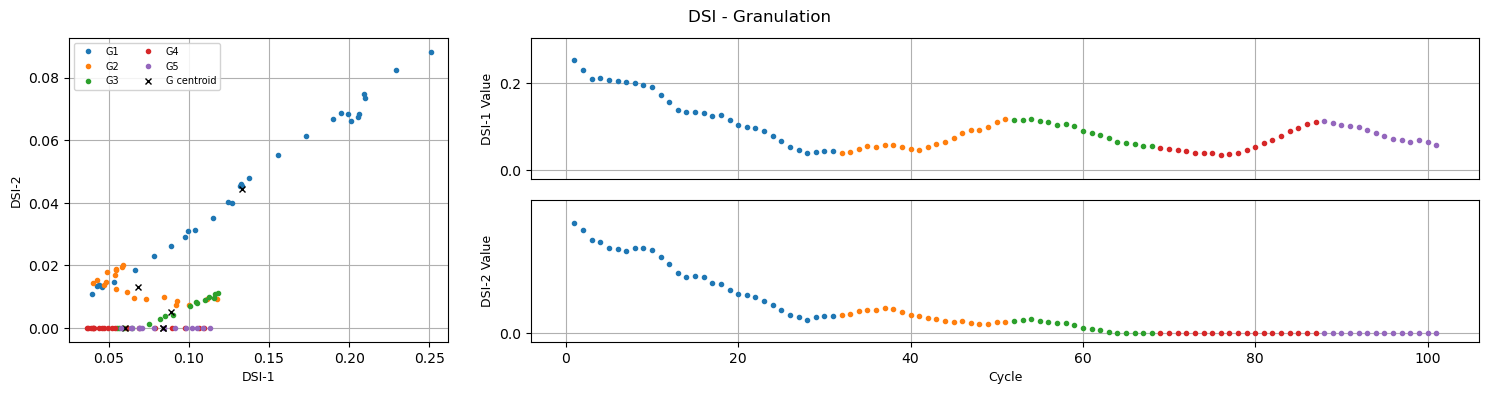

In [12]:
m, nRS, st, drop = Mp
init = (st+nRS)
df_RS = (pd.read_csv(os.path.join(dir_rs,brngs1[0])).abs()).iloc[:,:-1]
df_HI = (pd.read_csv(os.path.join(dir_hi,brngs1[0])).abs()).iloc[:,-1:]
if drop: df_RS = df_RS.drop(columns='Y')
RS = process_RS(df_RS,nRS)
HI = process_HI(df_HI,nHI=nHI,init=init)
xS,yS,zS = RS[st:-2], HI[:-1], HI[1:]

teda=AutoCloud(m=m, nS=len(xS[0]), nI=len(yS[0]), nR=nR, nO=len(yS[0]), 
                            ηS= [N1, N2, N3], tau=tau, decay=D,eol=0.2,
                            fator=1,st=init,end=len(df_RS)-init,wta=True,ep=0.1) 

for j,_ in enumerate(xS[:]):
    x,y,z= xS[j],yS[j],zS[j]
    teda.run(x)
    #teda.adapt(y,z)
    #teda.RUL_uncertainty(y,z)
    #teda.AddRUL()

#plot_2series(x1=teda.cycleP,x2=teda.cycleP,y1=teda.rulR,y2=teda.rulP, title=brng,s1='True',s2='Pred')
plot_DSI2(teda,ftrs=2,title='DSI - Granulation',ncol=2)
#plot_series(series=[[x,x,x,x],[yL,yP,yU,yR]],names=['L','P','U','R'],show=False)
#plot_RUL_CI(teda,startX=20,endX=120,endY=165)'''

In [4]:
for cloud in teda.c:
    cloud.calc_Dmax(teda.xI,teda.xF)
    cloud.calc_v(k=teda.k)
    print(cloud.Dmax, cloud.coverage, cloud.v)

1.087493588839689 0.46153846153846156 0.0
1.3752235295563795 0.15384615384615385 0.0
1.670738440286671 0.08653846153846154 [0.08653846]
1.7667257302653738 0.11538461538461539 [0.11538462]
1.7678930595112086 0.07692307692307693 [0.07692308]
1.76785430391461 0.10576923076923077 [0.10576923]


IndexError: list index out of range

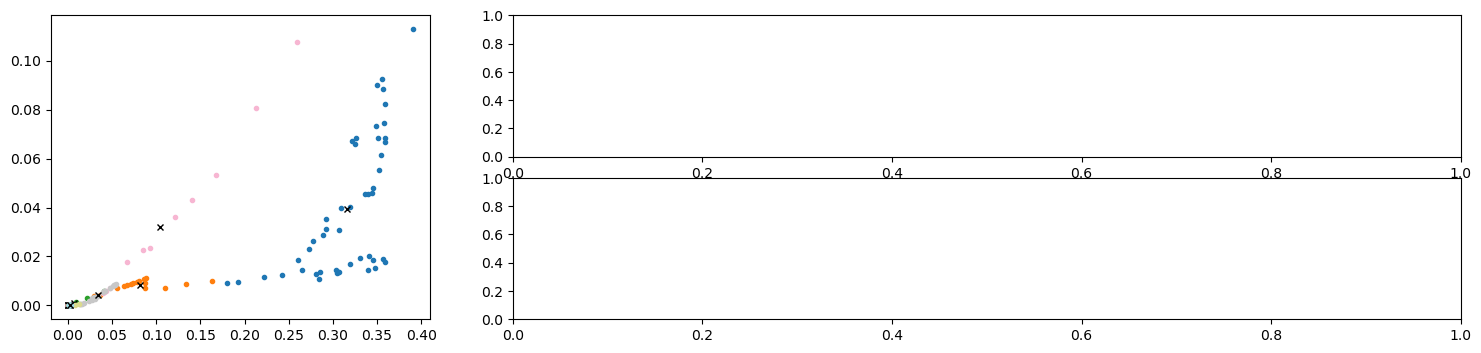

In [5]:
init = (st+nRS)
df_RS = (pd.read_csv(os.path.join(dir_rs,brngs1[1])).abs()).iloc[:,:-1]
df_HI = (pd.read_csv(os.path.join(dir_hi,brngs1[1])).abs()).iloc[:,-1:]
if drop: df_RS = df_RS.drop(columns='Y')
RS = process_RS(df_RS,nRS)
HI = process_HI(df_HI,nHI=nHI,init=init)
xS,yS,zS = RS[st:-2], HI[:-1], HI[1:]
teda.reset_rul()
for j,_ in enumerate(xS[:]):

    x,y,z= xS[j],yS[j],zS[j]
    teda.run(x)
    #teda.adapt(y,z)
    #teda.RUL_uncertainty(y,z)
    #teda.AddRUL()

#plot_2series(x1=teda.cycleP,x2=teda.cycleP,y1=teda.rulR,y2=teda.rulP, title=brng,s1='True',s2='Pred')
plot_DSI2(teda,ftrs=2,title='DSI - Granulation',ncol=2)
#plot_series(series=[[x,x,x,x],[yL,yP,yU,yR]],names=['L','P','U','R'],show=False)
#plot_RUL_CI(teda,startX=20,endX=120,endY=165)

In [ ]:
for cloud in teda.c:
    cloud.calc_Dmax(teda.xI,teda.xF)
    cloud.calc_v(k=teda.k)
    print(cloud.Dmax, cloud.coverage, cloud.v)

1.0379710842133583 0.028455284552845527 0.0284532884691827
1.7190851071786593 0.7479674796747967 0.7479674796747926
